# 11 個 quantile 的分位數比例法 GEV 參數估計

用分位數比例估計 GEV shape parameter $\xi$，再估計 $\sigma$，並檢查這個方法是否比目前 NN 估計更好。

這裡特別注意一件事：原本 NN 的訓練架構不是只看理論三個分位數，而是使用論文中 **11 個 quantiles** 作為輸入。因此本 notebook 不採用單一 $(0.25, 0.5, 0.75)$ 組合，而是先計算與 NN 完全相同的 11 個 empirical quantiles，再由這 11 個點形成多組 $(p_1,p_2,p_3)$ 做數值解，最後用成功解的 median 作為 QR11 估計。

本 notebook 包含三種資料：

1. 模擬資料：`data/processed/simulation_annual_max_grid.csv`，有 true $\mu,\sigma,\xi$ 可比較。
2. 真實網格資料：`data/processed/annual_max_grid_temperature.csv`，由 TCCIP 月最高溫網格資料整理成 annual maxima。
3. 真實 TCCIP GRID 資料：以每個網格點的時間序列比較 NN 與 QR11。

所有圖都採用 1 × 3 形式，依序呈現 $\mu$、$\sigma$、$\xi$。

## 0. 既有資料切法與 11 quantiles

TCCIP GRID 的資料切法來自 `src/tccip_grid_preprocessing.py`：

1. 讀取 `觀測_月資料_臺灣_最高溫_YYYY.csv`。
2. 將每年 12 個月份欄位轉成 long format：`date, station, lon, lat, max_temp`。
3. 將 `-99.9` 這類無效值改成缺值。
4. pivot 成 `Date × grid-station`。
5. 只保留 1980 年以後資料。
6. 每個 grid-station 的有效月份比例至少要達到 `0.80`。
7. 對每個 grid-station 做 annual block maxima。
8. 每個 grid-station 至少要有 30 年 annual maxima，這是為了對齊原始 NN 訓練資料的 sample size 下限。

NN 輸入的 11 個 quantiles 固定為：

```text
0.0001, 0.001, 0.01, 0.1, 0.25,
0.5, 0.75, 0.9, 0.99, 0.999, 0.9999
```

NN 的輸入是先對樣本做 median / IQR robust standardization 後，再取這 11 個 quantiles。QR11 的比例估計則使用原始尺度的 11 個 quantiles，因為後面要反推 $\sigma$ 與 $\mu$ 的原始單位。

In [16]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
from scipy.stats import genextreme as gev
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF, WhiteKernel

warnings.filterwarnings("ignore", category=UserWarning)

cwd = Path.cwd().resolve()
if (cwd / "src" / "project_paths.py").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src" / "project_paths.py").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("請從 repository 根目錄或 notebooks/ 執行。")

SRC_DIR = PROJECT_ROOT / "src"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
SHAPE_PATH = (
    PROJECT_ROOT
    / "data"
    / "shapefile"
    / "ne_50m_admin_0_countries"
    / "ne_50m_admin_0_countries.shp"
)
if not SHAPE_PATH.exists():
    raise FileNotFoundError("找不到 Taiwan shapefile，請確認 data/shapefile。")

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from quantile_ratio_estimator import P_SET_11, estimate_gev_quantile_ratio_11
from spatial_coordinates import add_twd97_km_columns, center_train_test_coordinates

plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "Arial", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("PROJECT_ROOT:", PROJECT_ROOT)
print("P_SET_11:", P_SET_11)


PROJECT_ROOT: c:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN_window_data
STATION_PROJECT_ROOT: c:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN
P_SET_11: [1.000e-04 1.000e-03 1.000e-02 1.000e-01 2.500e-01 5.000e-01 7.500e-01
 9.000e-01 9.900e-01 9.990e-01 9.999e-01]


In [17]:
p_set_table = pd.DataFrame({
    "index": range(len(P_SET_11)),
    "p": P_SET_11,
    "percentile": P_SET_11 * 100,
})
p_set_table

,index,p,percentile
0,0,0.0001,0.01
1,1,0.0010,0.10
2,2,0.0100,1.00
3,3,0.1000,10.00
4,4,0.2500,25.00
5,5,0.5000,50.00
6,6,0.7500,75.00
7,7,0.9000,90.00
8,8,0.9900,99.00
9,9,0.9990,99.90


## 1. 共用函式

下面函式負責四件事：

1. 對每個樣本計算 11 個 raw quantiles 與 11 個 standardized quantiles。
2. 用 11 個 raw quantiles 形成多組三分位比例，數值解 $\xi$。
3. 聚合每組成功解，得到一組 QR11 的 $\hat\mu,\hat\sigma,\hat\xi$。
4. 畫 1 × 3 參數圖。

`TRIPLET_MIN_INDEX_GAP = 2` 表示三個 quantiles 在 11 維向量中的 index 至少間隔 2，避免使用太接近的分位數造成 gap 太小、數值解不穩。若想使用所有三分位組合，可以改成 `1`。

本 notebook 的空間圖使用 `geopandas`：讀取臺灣 shapefile、建立 GeoDataFrame，並在 1 × 3 圖上疊加臺灣邊界。


In [18]:
TRIPLET_MIN_INDEX_GAP = 2


def clean_sample(y):
    y = np.asarray(y, dtype=float)
    return y[np.isfinite(y)]


def robust_standardize(y):
    y = clean_sample(y)
    med = np.median(y)
    q25, q75 = np.quantile(y, [0.25, 0.75])
    iqr = q75 - q25
    if iqr <= 1e-12:
        raise ValueError("IQR too small")
    z = (y - med) / iqr
    return z, med, iqr


def make_11_quantile_row(name, y):
    y = clean_sample(y)
    z, med, iqr = robust_standardize(y)
    raw_q = np.quantile(y, P_SET_11)
    std_q = np.quantile(z, P_SET_11)
    row = {"station": name, "n_obs": len(y), "median": med, "iqr": iqr}
    for p, q in zip(P_SET_11, raw_q):
        row[f"raw_q_{p:g}"] = q
    for p, q in zip(P_SET_11, std_q):
        row[f"std_q_{p:g}"] = q
    return row


def estimate_qr11_one(name, y):
    y = clean_sample(y)
    fit, detail = estimate_gev_quantile_ratio_11(
        y,
        probs=P_SET_11,
        min_index_gap=TRIPLET_MIN_INDEX_GAP,
    )
    row = {
        "station": name,
        "n_obs": len(y),
        "qr_mu_hat": fit["mu"],
        "qr_sigma_hat": fit["sigma"],
        "qr_log_sigma_hat": fit["log_sigma"],
        "qr_xi_hat": fit["xi"],
        "qr_n_success": fit["n_success"],
        "qr_n_root": fit["n_root"],
        "qr_n_bounded_min": fit["n_bounded_min"],
    }
    detail = detail.copy()
    detail.insert(0, "station", name)
    return row, detail


def estimate_qr11_from_wide_annual(annual_df, id_col):
    rows = []
    details = []
    quantile_rows = []
    station_cols = [c for c in annual_df.columns if c != id_col]
    for n, station in enumerate(station_cols, start=1):
        y = annual_df[station].to_numpy(dtype=float)
        y = clean_sample(y)
        if len(y) < 3:
            continue
        try:
            quantile_rows.append(make_11_quantile_row(station, y))
            row, detail = estimate_qr11_one(station, y)
            rows.append(row)
            details.append(detail)
        except Exception as exc:
            print(f"skip {station}: {exc}")
        if n % 200 == 0:
            print(f"processed {n}/{len(station_cols)}")
    detail_df = pd.concat(details, ignore_index=True) if details else pd.DataFrame()
    return pd.DataFrame(rows), detail_df, pd.DataFrame(quantile_rows)


def summarize_error(df, method_col, specs):
    rows = []
    for param, true_col, pred_col in specs:
        sub = df[[method_col, true_col, pred_col]].dropna()
        for method, g in sub.groupby(method_col):
            err = g[pred_col] - g[true_col]
            rows.append({
                "method": method,
                "param": param,
                "rmse": float(np.sqrt(np.mean(err ** 2))),
                "mae": float(np.mean(np.abs(err))),
                "bias": float(np.mean(err)),
                "correlation": float(g[[true_col, pred_col]].corr().iloc[0, 1]),
            })
    return pd.DataFrame(rows)


def load_taiwan_boundary():
    world = gpd.read_file(SHAPE_PATH).to_crs("EPSG:4326")
    name_cols = [c for c in ["NAME", "ADMIN", "NAME_EN"] if c in world.columns]
    taiwan = gpd.GeoDataFrame(columns=world.columns, crs=world.crs)
    for col in name_cols:
        hit = world[world[col].astype(str).str.contains("Taiwan", case=False, na=False)]
        if not hit.empty:
            taiwan = hit
            break
    if taiwan.empty:
        taiwan = world.cx[118:123, 21:26]
    return taiwan


TAIWAN_BOUNDARY = load_taiwan_boundary()


def to_taiwan_points_gdf(df):
    projected = add_twd97_km_columns(df)
    return gpd.GeoDataFrame(
        projected,
        geometry=gpd.points_from_xy(projected["x_km"], projected["y_km"]),
    )


def plot_three_param_points(df, cols, filename, suptitle, size=10, cmap="turbo"):
    plot_gdf = add_twd97_km_columns(to_taiwan_points_gdf(df))
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), dpi=150, constrained_layout=True)
    labels = ["mu", "sigma", "xi"]
    for ax, col, label in zip(axes, cols, labels):
        points = ax.scatter(plot_gdf["x_km"], plot_gdf["y_km"], c=plot_gdf[col], s=size, cmap=cmap)
        fig.colorbar(points, ax=ax, shrink=0.82, label=col)
        ax.set_title(label)
        ax.set_xlabel("TWD97 Easting (km)")
        ax.set_ylabel("TWD97 Northing (km)")
        ax.set_aspect("equal", adjustable="box")
    fig.suptitle(suptitle)
    out_path = FIG_DIR / filename
    fig.savefig(out_path)
    plt.show()
    print("saved:", out_path)


def plot_three_param_surface(df, cols, filename, suptitle, cmap="turbo"):
    plot_gdf = add_twd97_km_columns(to_taiwan_points_gdf(df))
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), dpi=150, constrained_layout=True)
    labels = ["mu", "sigma", "xi"]
    for ax, col, label in zip(axes, cols, labels):
        pivot = plot_gdf.pivot_table(index="y_km", columns="x_km", values=col)
        im = ax.imshow(
            pivot.values,
            origin="lower",
            extent=[pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()],
            cmap=cmap,
            aspect="auto",
        )
        ax.set_title(label)
        ax.set_xlabel("TWD97 Easting (km)")
        ax.set_ylabel("TWD97 Northing (km)")
        ax.set_aspect("equal", adjustable="box")
        fig.colorbar(im, ax=ax, shrink=0.82, label=col)
    fig.suptitle(suptitle)
    out_path = FIG_DIR / filename
    fig.savefig(out_path)
    plt.show()
    print("saved:", out_path)


def make_regular_grid_from_points(df, n_lon=90, n_lat=90):
    lon_grid = np.linspace(df["lon"].min(), df["lon"].max(), n_lon)
    lat_grid = np.linspace(df["lat"].min(), df["lat"].max(), n_lat)
    grid_raw = np.array([(lon, lat) for lat in lat_grid for lon in lon_grid])
    grid_df = add_twd97_km_columns(pd.DataFrame(grid_raw, columns=["lon", "lat"]))
    return grid_df[["x_km", "y_km"]].to_numpy(), grid_df


def fit_gp_and_predict(df, target_col, grid_raw, max_train=800):
    train_df = add_twd97_km_columns(df[["lon", "lat", target_col]].dropna().copy())
    if len(train_df) > max_train:
        train_df = train_df.sample(max_train, random_state=123)

    x, x_grid, _ = center_train_test_coordinates(
        train_df[["x_km", "y_km"]].to_numpy(), grid_raw
    )
    y = train_df[target_col].to_numpy()

    kernel = C(1.0, (1e-2, 1e2)) * RBF(length_scale=50.0, length_scale_bounds=(1.0, 500.0)) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-8, 1e-1))
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=2, normalize_y=True, random_state=123)
    gp.fit(x, y)
    pred, std = gp.predict(x_grid, return_std=True)
    return pred, std, str(gp.kernel_), len(train_df)

## 2. 模擬資料：有 true parameter，可以直接比較準確度

模擬資料來自 `src/tccip_grid_preprocessing.py` 的模擬區段：先在 0.5 度網格上產生 true $\mu,\sigma,\xi$ surface，再從每個格點的 GEV 分布模擬 45 年 annual maxima。

這一段會：

1. 對每個模擬格點計算 11 個 quantiles。
2. 使用 QR11 數值解估計 $\mu,\sigma,\xi$。
3. 和 `simulation_station_true_vs_nn.csv` 中的 NN 結果比較。
4. 畫 true、NN、QR11 三組 1 × 3 圖。

In [19]:
sim_annual_path = PROCESSED_DIR / "simulation_annual_max_grid.csv"
sim_true_path = PROCESSED_DIR / "simulation_true_grid_gev_params.csv"
sim_nn_path = PROCESSED_DIR / "simulation_station_true_vs_nn.csv"

for path in [sim_annual_path, sim_true_path, sim_nn_path]:
    if not path.exists():
        raise FileNotFoundError(f"找不到 {path}，請先執行 python src/tccip_grid_preprocessing.py。")

sim_annual = pd.read_csv(sim_annual_path)
sim_true = pd.read_csv(sim_true_path)
sim_nn = pd.read_csv(sim_nn_path)

sim_qr, sim_detail, sim_quantiles = estimate_qr11_from_wide_annual(sim_annual, id_col="year")
sim_qr = sim_qr.merge(sim_true[["station", "lon", "lat", "true_mu", "true_sigma", "true_xi"]], on="station", how="left")

sim_qr.to_csv(PROCESSED_DIR / "simulation_station_true_vs_qr11.csv", index=False, encoding="utf-8-sig")
sim_detail.to_csv(PROCESSED_DIR / "simulation_qr11_detail.csv", index=False, encoding="utf-8-sig")
sim_quantiles.to_csv(PROCESSED_DIR / "simulation_11_quantiles.csv", index=False, encoding="utf-8-sig")

sim_qr.head()

,station,n_obs,qr_mu_hat,qr_sigma_hat,qr_log_sigma_hat,qr_xi_hat,qr_n_success,qr_n_root,qr_n_bounded_min,lon,lat,true_mu,true_sigma,true_xi
0,SIM119.0_21.5,45,29.141428,1.146655,0.136849,0.039423,84,80,4,119.0,21.5,28.874383,0.996960,0.117391
1,SIM119.5_21.5,45,27.768387,0.944605,-0.056988,0.096179,84,82,2,119.5,21.5,27.907660,1.043073,0.104280
2,SIM120.0_21.5,45,26.611301,0.843670,-0.169994,0.017013,84,74,10,120.0,21.5,26.567435,1.106493,0.084785
3,SIM120.5_21.5,45,26.607949,0.810666,-0.209899,-0.073096,84,79,5,120.5,21.5,26.498254,1.152340,0.070773
4,SIM121.0_21.5,45,27.804817,1.077863,0.074980,0.034838,84,76,8,121.0,21.5,27.328246,1.152340,0.070773


In [20]:
# TCCIP GRID 主流程的 NN 模擬輸出已經正確提供 EVT xi_hat。
sim_compare = pd.concat(
    [
        sim_nn[["station", "lon", "lat", "true_mu", "true_sigma", "true_xi", "mu_hat", "sigma_hat", "xi_hat"]]
        .rename(columns={"mu_hat": "pred_mu", "sigma_hat": "pred_sigma", "xi_hat": "pred_xi"})
        .assign(method="NN"),
        sim_qr[["station", "lon", "lat", "true_mu", "true_sigma", "true_xi", "qr_mu_hat", "qr_sigma_hat", "qr_xi_hat"]]
        .rename(columns={"qr_mu_hat": "pred_mu", "qr_sigma_hat": "pred_sigma", "qr_xi_hat": "pred_xi"})
        .assign(method="QR11"),
    ],
    ignore_index=True,
)

sim_error = summarize_error(
    sim_compare,
    method_col="method",
    specs=[
        ("mu", "true_mu", "pred_mu"),
        ("sigma", "true_sigma", "pred_sigma"),
        ("xi", "true_xi", "pred_xi"),
    ],
)
sim_error.to_csv(PROCESSED_DIR / "simulation_qr11_error_summary.csv", index=False, encoding="utf-8-sig")
sim_error

,method,param,rmse,mae,bias,correlation
0,NN,mu,0.220263,0.169348,0.021410,0.994105
1,QR11,mu,0.231538,0.176861,0.070541,0.994123
2,NN,sigma,0.403688,0.368090,-0.362858,0.502011
3,QR11,sigma,0.262775,0.227154,-0.209361,0.599971
4,NN,xi,0.134200,0.109400,0.023789,0.293797
5,QR11,xi,0.120039,0.098527,-0.083030,0.295335


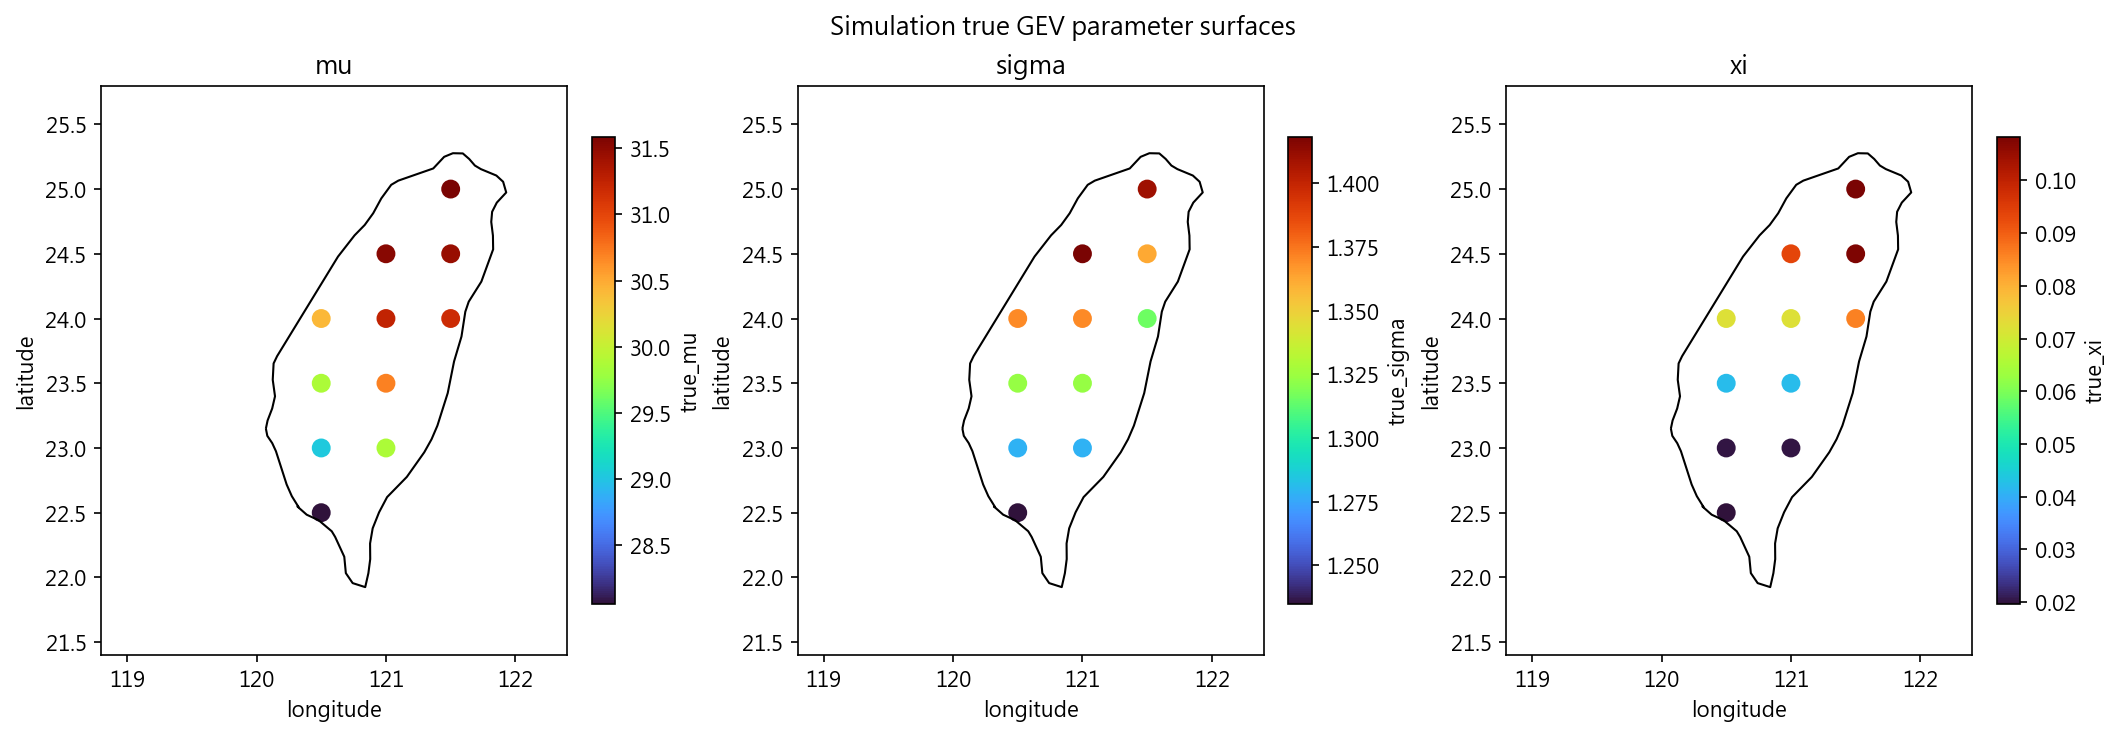

saved: c:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN_window_data\results\figures\qr11_simulation_true_1x3.png


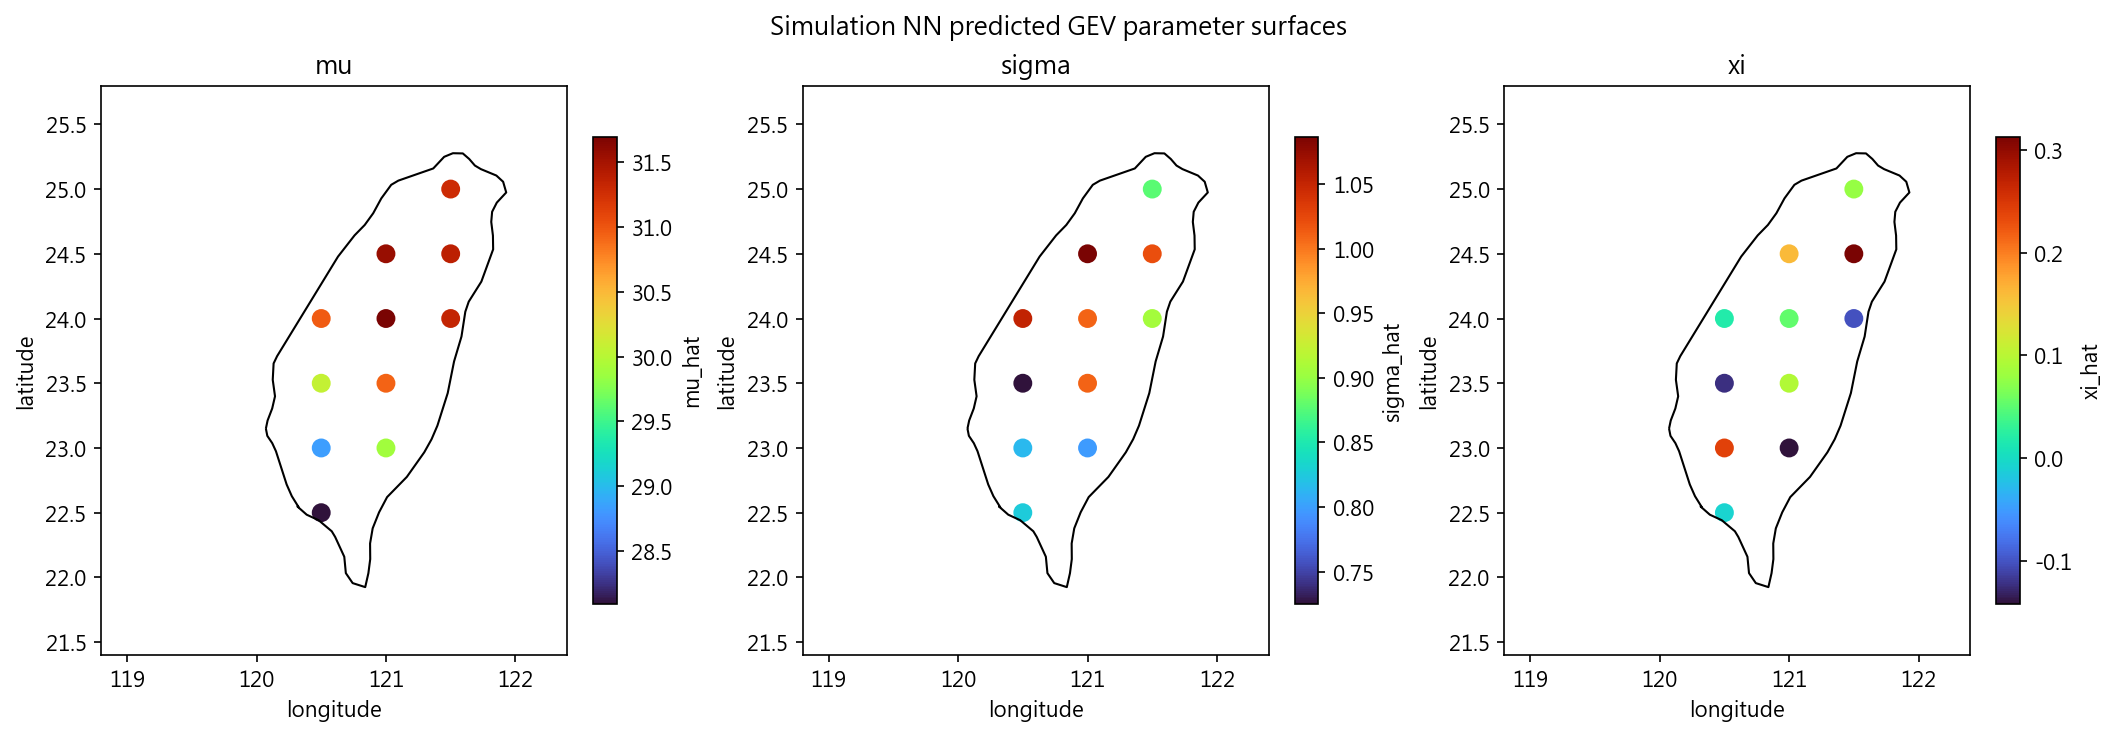

saved: c:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN_window_data\results\figures\qr11_simulation_nn_1x3.png


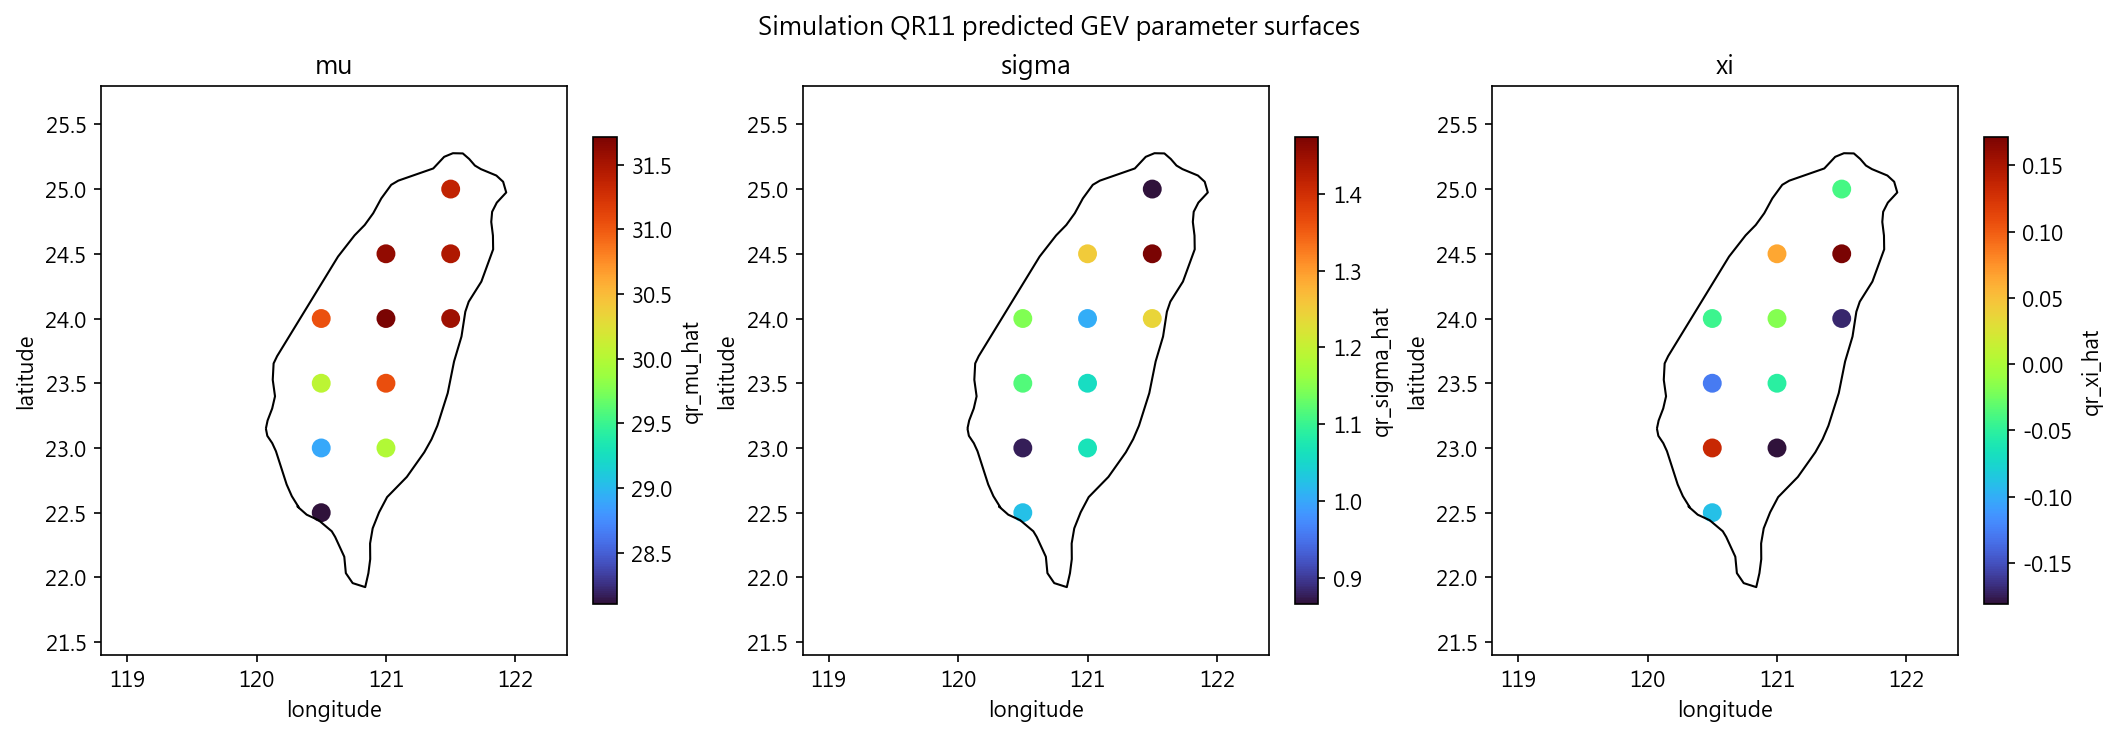

saved: c:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN_window_data\results\figures\qr11_simulation_qr_1x3.png


In [21]:
plot_three_param_points(
    sim_qr,
    ["true_mu", "true_sigma", "true_xi"],
    "qr11_simulation_true_1x3.png",
    "Simulation true GEV parameter surfaces",
    size=65,
)
plot_three_param_points(
    sim_nn,
    ["mu_hat", "sigma_hat", "xi_hat"],
    "qr11_simulation_nn_1x3.png",
    "Simulation NN predicted GEV parameter surfaces",
    size=65,
)
plot_three_param_points(
    sim_qr,
    ["qr_mu_hat", "qr_sigma_hat", "qr_xi_hat"],
    "qr11_simulation_qr_1x3.png",
    "Simulation QR11 predicted GEV parameter surfaces",
    size=65,
)

## 3. 真實網格資料：TCCIP window-data annual maxima

真實網格資料沒有 true GEV parameter，因此這裡比較的是 NN 與 QR11 在同一批 annual maxima 上得到的參數場差異。

注意：TCCIP GRID 主流程在真實網格區塊中輸出的 `xi_hat` 實際上是 NN 原始 shape `c`，而 EVT 慣用的 shape 是 `xi = -c`。因此本 notebook 會建立 `nn_xi_evt = -xi_hat` 來和 QR11 的 `qr_xi_hat` 比較。

In [22]:
real_grid_annual_path = PROCESSED_DIR / "annual_max_grid_temperature.csv"
real_grid_loc_path = PROCESSED_DIR / "annual_grid_station_location.csv"
real_grid_nn_path = PROCESSED_DIR / "grid_station_gev_params_with_loc.csv"

for path in [real_grid_annual_path, real_grid_loc_path, real_grid_nn_path]:
    if not path.exists():
        raise FileNotFoundError(f"找不到 {path}，請先執行 python src/tccip_grid_preprocessing.py。")

real_grid_annual = pd.read_csv(real_grid_annual_path)
real_grid_loc = pd.read_csv(real_grid_loc_path)
real_grid_nn = pd.read_csv(real_grid_nn_path)
real_grid_nn["nn_xi_evt"] = -real_grid_nn["xi_hat"]

real_grid_qr, real_grid_detail, real_grid_quantiles = estimate_qr11_from_wide_annual(real_grid_annual, id_col="year")
real_grid_qr = real_grid_qr.merge(real_grid_loc, on="station", how="left")

real_grid_qr.to_csv(PROCESSED_DIR / "real_grid_station_qr11_estimates.csv", index=False, encoding="utf-8-sig")
real_grid_detail.to_csv(PROCESSED_DIR / "real_grid_qr11_detail.csv", index=False, encoding="utf-8-sig")
real_grid_quantiles.to_csv(PROCESSED_DIR / "real_grid_11_quantiles.csv", index=False, encoding="utf-8-sig")

real_grid_qr.head()

processed 200/1412
processed 400/1412
processed 600/1412
processed 800/1412
processed 1000/1412
processed 1200/1412
processed 1400/1412


,station,n_obs,qr_mu_hat,qr_sigma_hat,qr_log_sigma_hat,qr_xi_hat,qr_n_success,qr_n_root,qr_n_bounded_min,lat,lon
0,G122.00_25.05,45,32.186231,0.552722,-0.592899,-0.205741,84,71,13,25.05,122.00
1,G119.45_23.20,45,31.723783,0.581049,-0.542920,-0.216700,84,75,9,23.20,119.45
2,G119.50_23.35,45,31.690631,0.577563,-0.548937,-0.179953,84,79,5,23.35,119.50
3,G121.80_24.45,45,31.970791,0.560622,-0.578708,-0.175145,84,75,9,24.45,121.80
4,G121.80_24.50,45,30.079890,0.648569,-0.432986,-0.197559,84,67,17,24.50,121.80


In [23]:
real_grid_compare = real_grid_nn[["station", "mu_hat", "sigma_hat", "nn_xi_evt"]].merge(
    real_grid_qr[["station", "qr_mu_hat", "qr_sigma_hat", "qr_xi_hat", "qr_n_success", "qr_n_root", "qr_n_bounded_min"]],
    on="station",
    how="inner",
)
real_grid_compare["diff_mu_qr_minus_nn"] = real_grid_compare["qr_mu_hat"] - real_grid_compare["mu_hat"]
real_grid_compare["diff_sigma_qr_minus_nn"] = real_grid_compare["qr_sigma_hat"] - real_grid_compare["sigma_hat"]
real_grid_compare["diff_xi_qr_minus_nn"] = real_grid_compare["qr_xi_hat"] - real_grid_compare["nn_xi_evt"]
real_grid_compare.to_csv(PROCESSED_DIR / "real_grid_qr11_vs_nn_summary_rows.csv", index=False, encoding="utf-8-sig")

real_grid_compare[["mu_hat", "qr_mu_hat", "sigma_hat", "qr_sigma_hat", "nn_xi_evt", "qr_xi_hat", "qr_n_root"]].describe().T

,count,mean,std,min,25%,50%,75%,max
mu_hat,1412.0,29.246515,4.131927,16.399114,26.837373,31.162321,32.410737,33.948245
qr_mu_hat,1412.0,29.265753,4.132169,16.450944,26.867889,31.168192,32.432513,33.977064
sigma_hat,1412.0,0.371804,0.145508,0.090590,0.285479,0.349497,0.423332,1.075406
qr_sigma_hat,1412.0,0.583050,0.156059,0.338272,0.475080,0.542660,0.643405,1.398802
nn_xi_evt,1412.0,-0.129251,0.116656,-0.393741,-0.218774,-0.142929,-0.062110,0.360854
qr_xi_hat,1412.0,-0.155041,0.078370,-0.440437,-0.206408,-0.154077,-0.104254,0.085569
qr_n_root,1412.0,74.216714,6.469669,45.000000,71.000000,75.000000,79.000000,84.000000


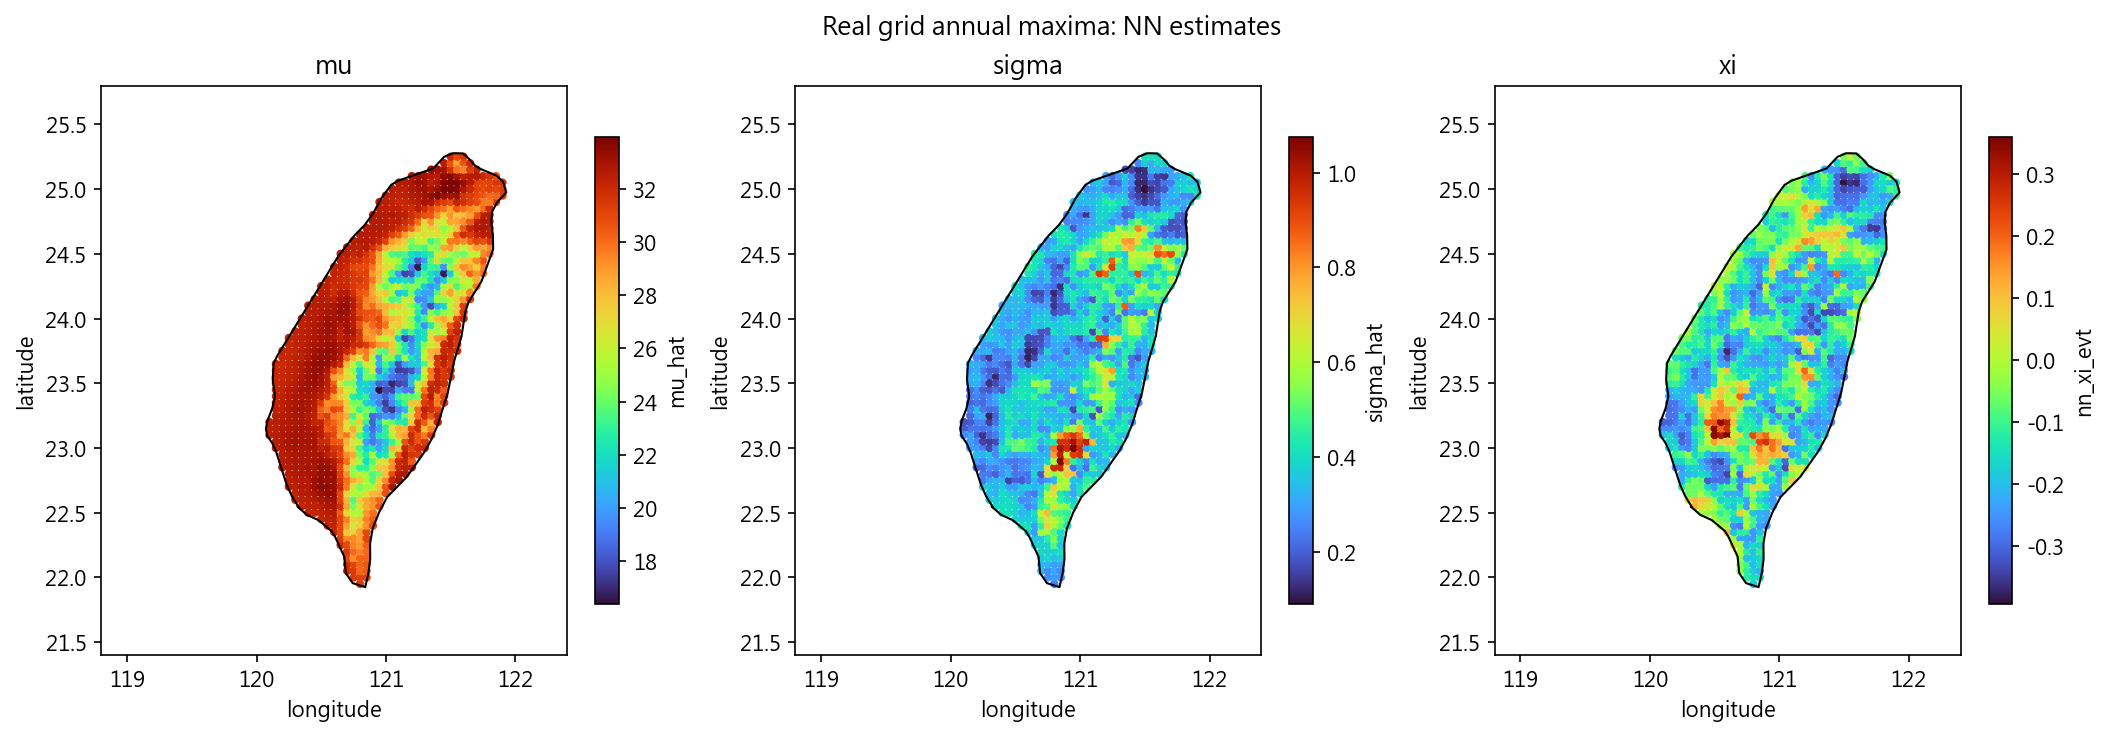

saved: c:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN_window_data\results\figures\qr11_real_grid_nn_1x3.png


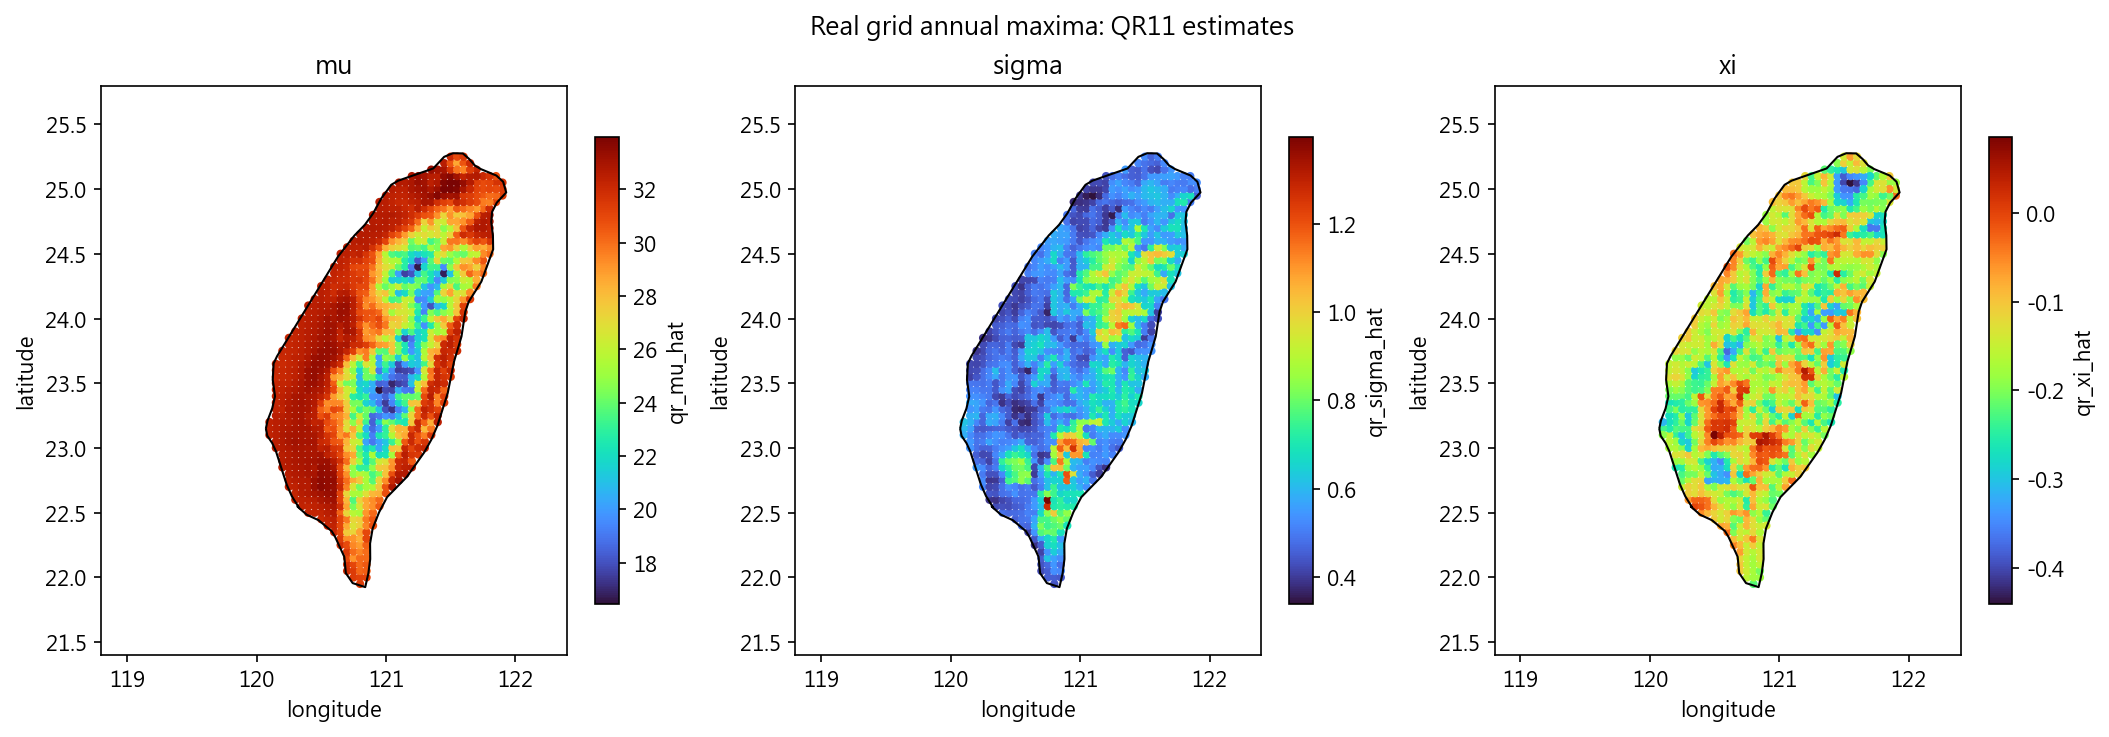

saved: c:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN_window_data\results\figures\qr11_real_grid_qr_1x3.png


In [24]:
plot_three_param_points(
    real_grid_nn,
    ["mu_hat", "sigma_hat", "nn_xi_evt"],
    "qr11_real_grid_nn_1x3.png",
    "Real grid annual maxima: NN estimates",
    size=9,
)
plot_three_param_points(
    real_grid_qr,
    ["qr_mu_hat", "qr_sigma_hat", "qr_xi_hat"],
    "qr11_real_grid_qr_1x3.png",
    "Real grid annual maxima: QR11 estimates",
    size=9,
)

### 3.1 將 QR11 真實網格估計做 Kriging 平滑

原本 window-data 專案會把 NN 估計出的 grid-station 參數再做 Gaussian process / Kriging 平滑，輸出 `kriging_grid_gev_params.csv`。這裡對 QR11 也做同樣事情，方便和原本流程對照。

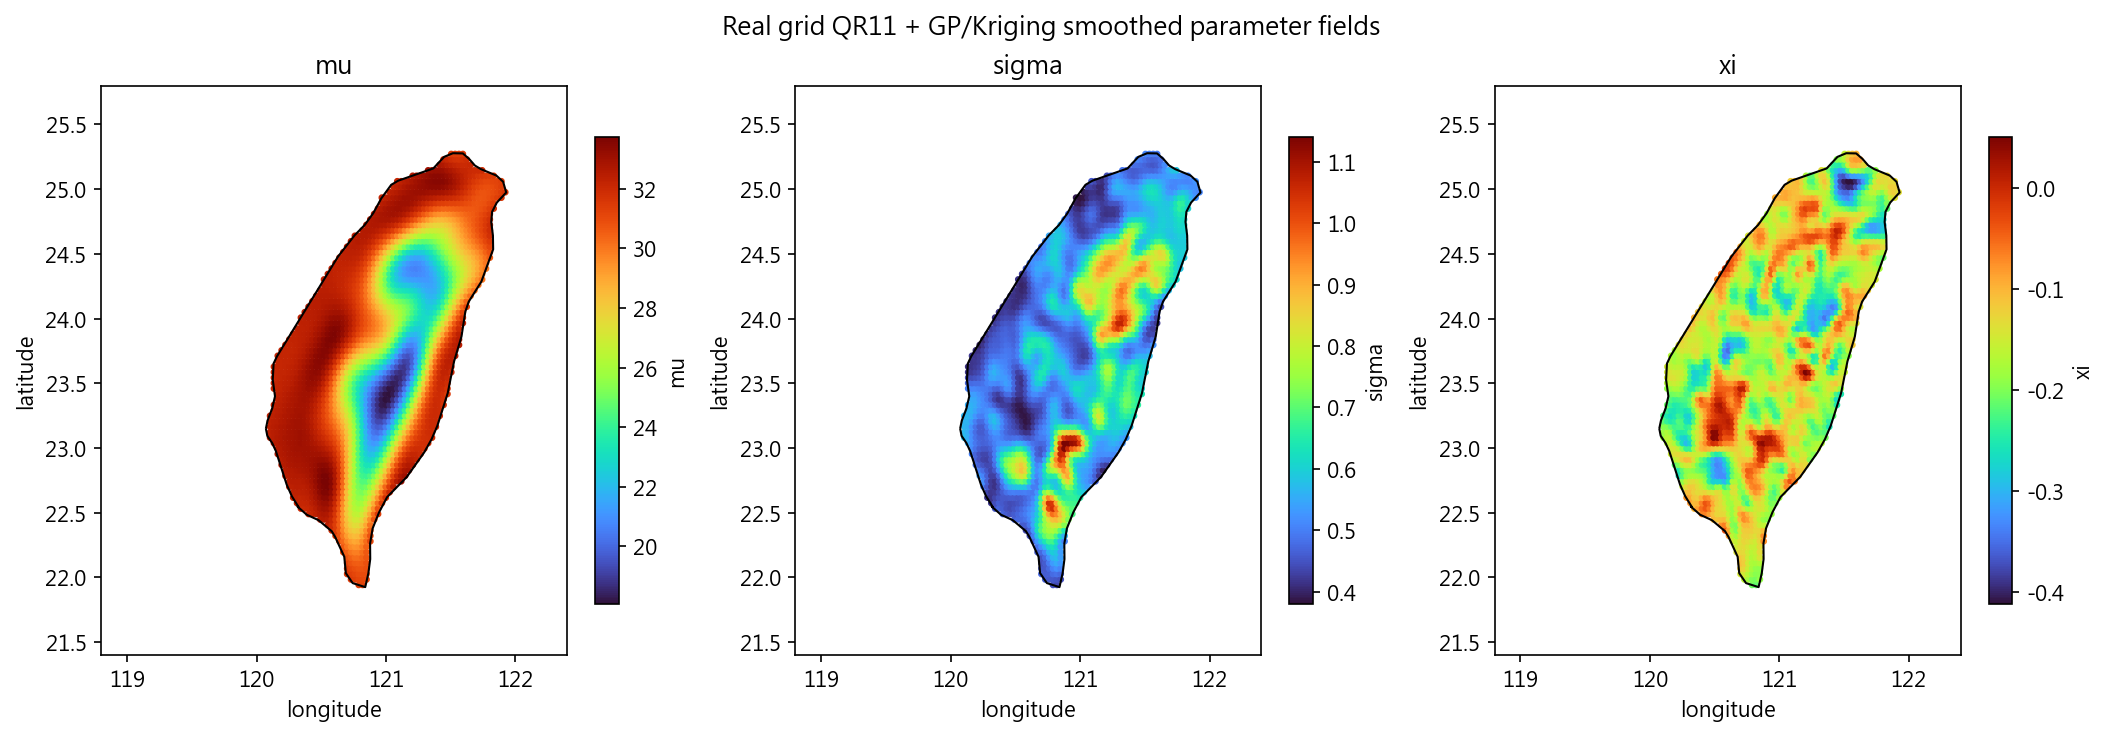

saved: c:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN_window_data\results\figures\qr11_real_grid_kriging_1x3.png


,lon,lat,mu,mu_std,log_sigma,log_sigma_std,xi,xi_std,sigma
0,119.450000,21.9,29.287840,3.272458,-0.575814,0.205071,-0.155789,0.07358,0.562247
1,119.479775,21.9,29.287840,3.272458,-0.575814,0.205071,-0.155789,0.07358,0.562247
2,119.509551,21.9,29.287841,3.272458,-0.575814,0.205071,-0.155789,0.07358,0.562247
3,119.539326,21.9,29.287841,3.272458,-0.575814,0.205071,-0.155789,0.07358,0.562247
4,119.569101,21.9,29.287843,3.272458,-0.575814,0.205071,-0.155789,0.07358,0.562247


In [25]:
lon_grid = np.linspace(real_grid_qr["lon"].min(), real_grid_qr["lon"].max(), 90)
lat_grid = np.linspace(real_grid_qr["lat"].min(), real_grid_qr["lat"].max(), 90)
grid_raw = np.array([(lon, lat) for lat in lat_grid for lon in lon_grid])
qr_grid_out = pd.DataFrame(grid_raw, columns=["lon", "lat"])

kernel_rows = []
for source_col, out_col in [
    ("qr_mu_hat", "mu"),
    ("qr_log_sigma_hat", "log_sigma"),
    ("qr_xi_hat", "xi"),
]:
    pred, std, kernel_text, n_train = fit_gp_and_predict(real_grid_qr, source_col, grid_raw)
    qr_grid_out[out_col] = pred
    qr_grid_out[f"{out_col}_std"] = std
    kernel_rows.append({"target": out_col, "n_train_used": n_train, "kernel": kernel_text})

qr_grid_out["sigma"] = np.exp(qr_grid_out["log_sigma"])
qr_grid_out.to_csv(PROCESSED_DIR / "real_grid_kriging_qr11_params.csv", index=False, encoding="utf-8-sig")
pd.DataFrame(kernel_rows).to_csv(PROCESSED_DIR / "real_grid_kriging_qr11_kernel_summary.csv", index=False, encoding="utf-8-sig")

plot_three_param_points(
    qr_grid_out,
    ["mu", "sigma", "xi"],
    "qr11_real_grid_kriging_1x3.png",
    "Real grid QR11 + GP/Kriging smoothed parameter fields",
    size=5,
)

qr_grid_out.head()